# Comparison of DRT Software

# Testing DRTs

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd


from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots.eis_plot import NyquistPlot
from redoxed.plots.drt_plot import DRTPlot
from redoxed.impedance import DRTData

import pyDRTtools

from pyimpspec import (
  DataSet,
  DRTResult,              # An abstract class for DRT results
  calculate_drt,          # Wrapper function for all methods
  generate_mock_data,
)
from pyimpspec.analysis.drt import (
  BHTResult,              # Result of the BHT method
  LMResult,               # Result of the Loewner method
  MRQFitResult,           # Result of the m(RQ)fit method
  TRNNLSResult,           # Result of the TR-NNLS method
  TRRBFResult,            # Result of the TR-RBF method
  calculate_drt_bht,      # BHT method
  calculate_drt_lm,       # Loewner method
  calculate_drt_mrq_fit,  # m(RQ)fit method
  calculate_drt_tr_nnls,  # TR-NNLS method
  calculate_drt_tr_rbf,   # TR-RBF method
)



from nanodrt.dataobjects.dataobject import EISDataObject
from nanodrt.calculators import ImpedanceCalculator
from nanodrt.radialbasisfunctions import GaussianRBF
from nanodrt.optimizers import ImpedanceOptimizer
import jax.numpy as jnp

%matplotlib inline

Initializing pyDRTtools from c:\users\es758\documents\github\pydrttools
['c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\python313.zip', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\DLLs', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758', '', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages', 'C:\\Users\\es758\\Documents\\GitHub\\redoxED\\src', 'c:\\users\\es758\\documents\\github\\pydrttools', 'c:\\users\\es758\\documents\\github\\nanodrt', 'C:\\Users\\es758\\Documents\\GitHub\\phd_tools', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\Pythonwin', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\yadg']
Imported basics
Imported BHT
Imported cli
Imported GUI
Imported HMC
Imported layout
Imported nearest_PD
Imported parameter_sele

## Prepare data

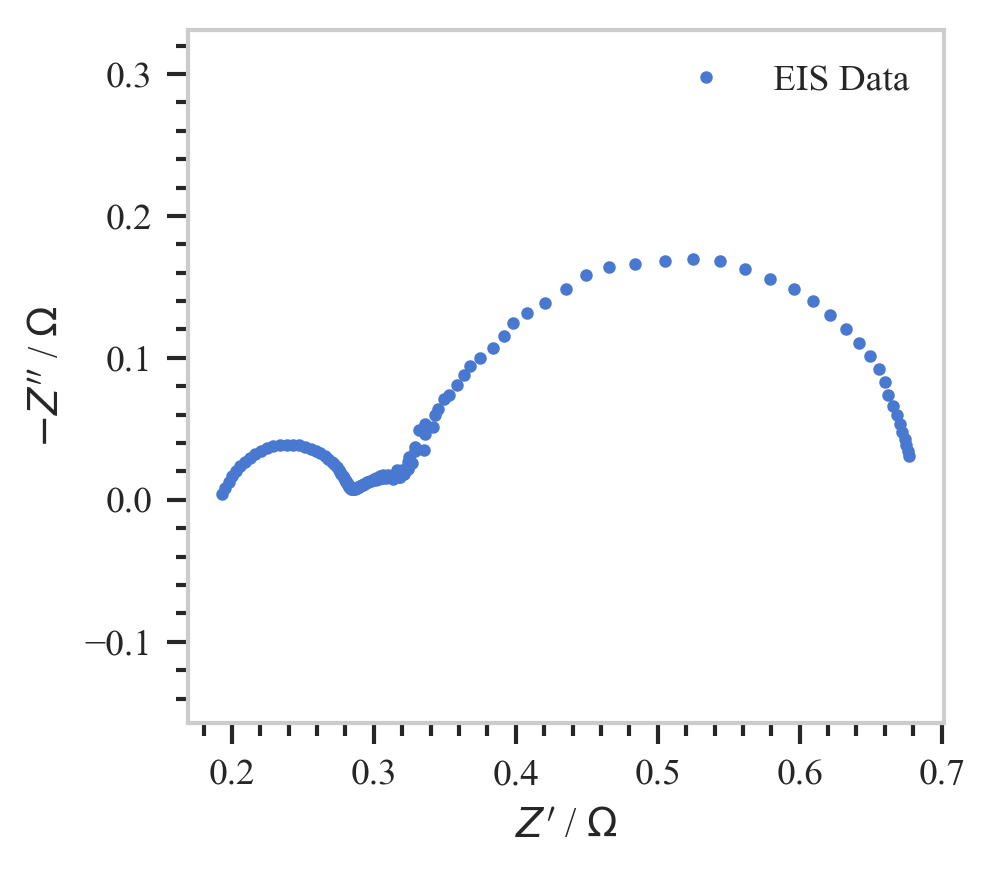

In [2]:
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Documents\Lent 2025\time_data\30787_EIS_data.csv"
data = CSVLoader().load_data(fpath=fpath)   
data.df
column_mapping = {
            "Z_re": "Z_re",
            "-Z_im": None,
            "f": "f",
            "Z": None,
            "Z_im": 'Z_im',
        }
EISData_object = data.to_EISData(column_mapping=column_mapping)

EISData_object.trim_inductive()


data_plot = NyquistPlot(figsize=(3.25, 3), dpi=300) 
data_plot.add_plot(EISData_object, label = "EIS Data", linestyle = "", marker = "o", markersize = 2)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
data_plot.add_major_ticks(major_tick_spacing = 0.1)
data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
data_plot.ax.legend()

display(data_plot.fig)

In [ ]:
# without cables
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\13_last_repeat_overnightbreak_04_GEIS_C02.mpr"
# with cables
"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.04.23 FB1_DHPS_FCN_E620K_GFDBO_B3\16_cables_banana_bigloop_01_GEIS_C02.mpr"

## pyDRTtools

c:\users\es758\documents\github\pydrttools\pyDRTtools\basics.py:59: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  out_val = integrate.quad(integrand_g_i, -50, 50, epsabs=1E-9, epsrel=1E-9)
c:\users\es758\documents\github\pydrttools\pyDRTtools\basics.py:92: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  out_val = integrate.quad(integrand_g_ii, -50, 50, epsabs=1E-9, epsrel=1E-9)


The value of the regularization parameter is 1e-09
     pcost       dcost       gap    pres   dres
 0: -2.0337e+01 -2.2723e+01  2e+02  1e+01  6e-05
 1: -1.8790e+01 -2.4157e+01  8e+00  2e-01  9e-07
 2: -1.9929e+01 -2.1263e+01  1e+00  2e-02  8e-08
 3: -2.0231e+01 -2.0566e+01  3e-01  3e-03  1e-08
 4: -2.0318e+01 -2.0444e+01  1e-01  3e-05  1e-10
 5: -2.0343e+01 -2.0364e+01  2e-02  4e-07  2e-12
 6: -2.0349e+01 -2.0352e+01  3e-03  4e-09  2e-14
 7: -2.0350e+01 -2.0351e+01  2e-03  1e-16  1e-16
 8: -2.0350e+01 -2.0350e+01  3e-04  3e-16  3e-16
 9: -2.0350e+01 -2.0350e+01  1e-04  3e-16  2e-16
10: -2.0350e+01 -2.0350e+01  2e-05  2e-16  4e-16
Optimal solution found.


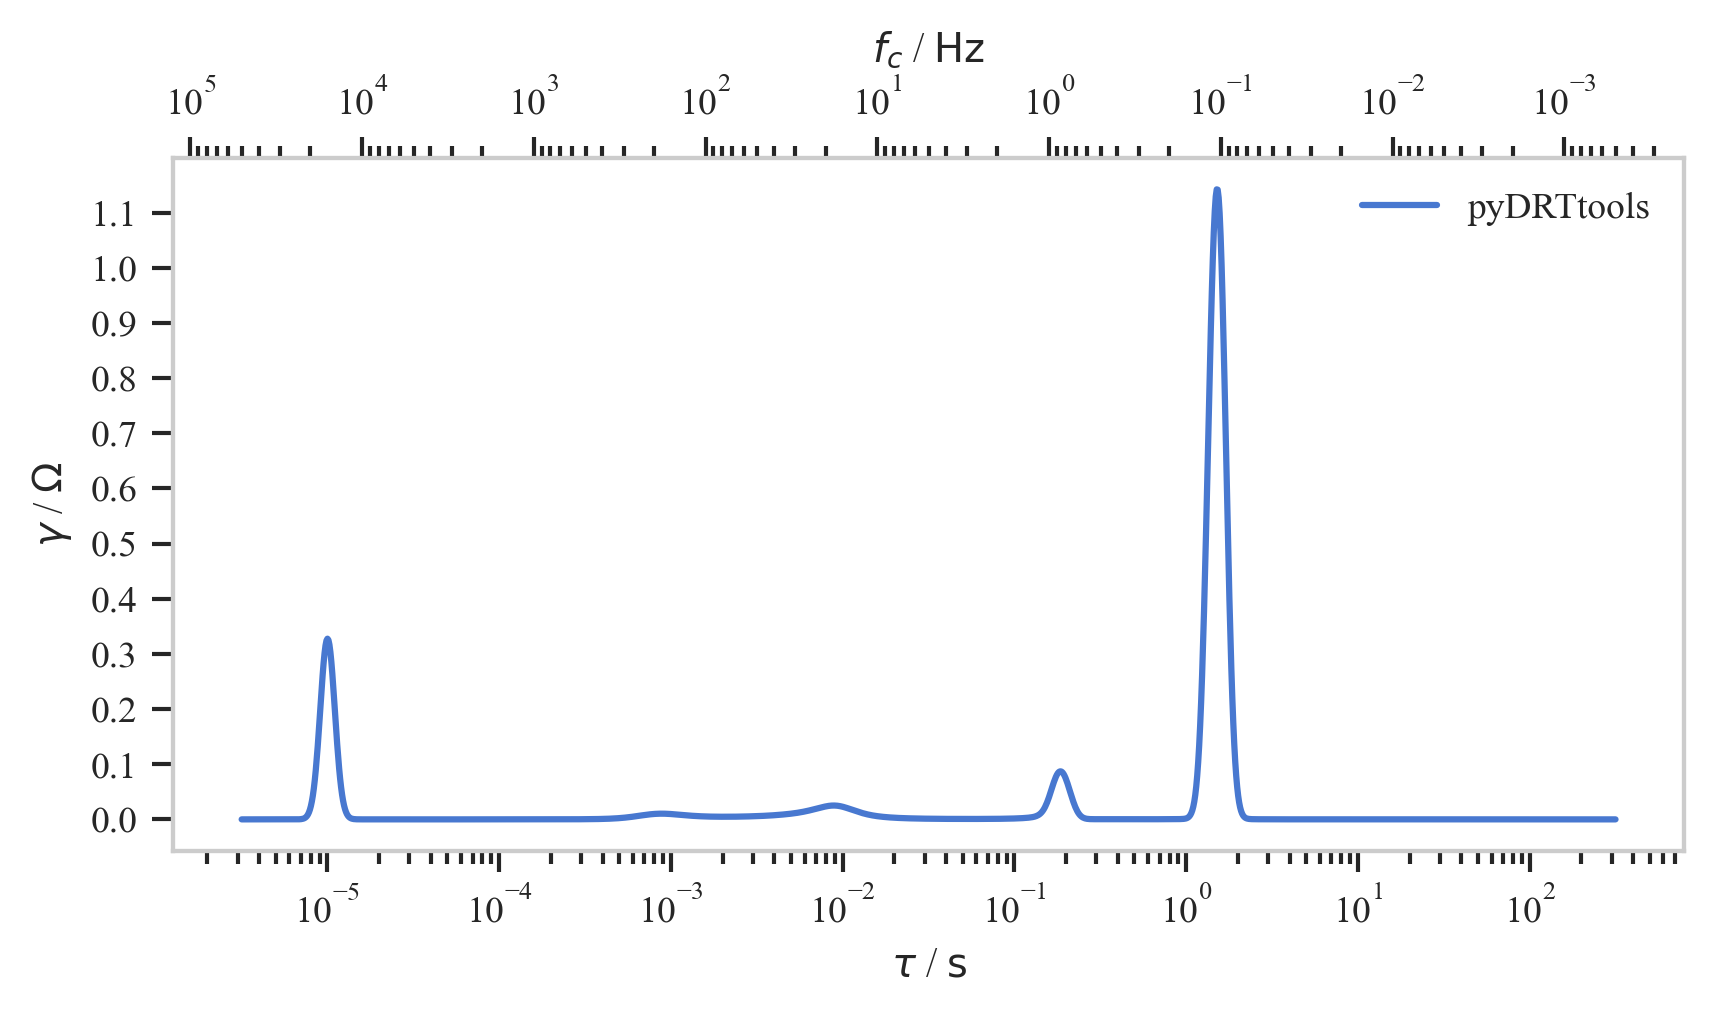

In [4]:
# Load measurement data into EIS_object
pyDRTtools_EIS_object = pyDRTtools.runs.EIS_object(
    EISData_object.f, EISData_object.Z_re, EISData_object.Z_im, ed_adjust = False
)
# this includes tau definition of
# # self.tau = 1/freq # we assume that the collocation points equal to 1/freq as default
# # self.tau_fine  = np.logspace(log10(self.tau.min())-0.5,log10(self.tau.max())+0.5,10*freq.shape[0])


induct_used = 1 # 1 means do keep inductive and fit inductance.
der_used = '1st order'
cv_type = 'custom' # fix lambda
lambda_0 = 1e-9 # initial guess
reg_param = lambda_0
shape_control = "FWHM Coefficient" # otherwise coeff is treated as their definition of shape factor mu
coeff = 0.5 # FWHM twice log spacing means coef 0.5. Is done so there is good overlap.
rbf_type = "Gaussian" # Gaussian is the default, but can also use 'Cauchy', 'Lorentzian', 'Exponential', 'Polynomial', 'Ridge' or 'Laplacian'
data_used = "Combined Re-Im Data"
# ridge regression DRT
fitted_entry = pyDRTtools.runs.simple_run(
    entry=pyDRTtools_EIS_object,
    rbf_type=rbf_type,
    data_used=data_used,
    induct_used=induct_used,
    der_used=der_used,
    cv_type=cv_type,
    reg_param=reg_param,
    shape_control=shape_control,
    coeff=coeff,
)
### If want to mute the console, can use something like this with simple_run nested in
# # Redirecting stdout to capture the output
# with io.StringIO() as output, contextlib.redirect_stdout(output):

gamma_pyDRTtools = fitted_entry.gamma # is tau_fine from DRTtools, not tau used for fitting x. padded values.
tau_pyDRTtools = fitted_entry.out_tau_vec
DRT_object_pyDRTtools = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = "pyDRTtools")

data_plot = DRTPlot(figsize=(6.5, 3), dpi=300) 
data_plot.add_plot(DRT_object_pyDRTtools, linestyle = "-", marker = "")

### Plot formatting
## Cropping
# data_plot.ax.set_ylim([0.01, None]) 
## Embellishments
data_plot.add_major_ticks(major_tick_spacing = 0.1)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
data_plot.ax.legend()

data_plot.add_fc_axis()

display(data_plot.fig)


# fitted_entry.gamma
# fitted_entry.R
# fitted_entry.L
# lambda_value = fitted_entry.lambda_value

# df_temp = {
#     "freq/Hz": fitted_entry.freq,
#     "Re(Z)/Ohm": fitted_entry.mu_Z_re,
#     "-Im(Z)/Ohm": -fitted_entry.mu_Z_im,
# }  # prepare df
# df_temp = pd.DataFrame(df_temp)  # convert to pd df
# # self.EIS_data_fit = EIS_data(
# #     df_temp, dataset_type="fitted"


## pyimpspec

In [ ]:
data: DataSet = DataSet(frequencies = eis_object.f, impedances = eis_object.Z, mask = None, path = "", label = "", uuid = "")
#drt: TRNNLSResult = calculate_drt_tr_nnls(data, lambda_value=1e-4)
drt = calculate_drt_tr_rbf(data, mode= 'complex', method="tr-rbf", lambda_value=1e-99, cross_validation='', inductance = True, derivative_order = 1, rbf_shape = 'fwhm')

# def calculate_drt_tr_rbf(
#     data: DataSet,
#     mode: str = "complex",
#     lambda_value: float = -1.0,
#     cross_validation: str = "mgcv",
#     rbf_type: str = "gaussian",
#     derivative_order: int = 1,
#     rbf_shape: str = "fwhm",
#     shape_coeff: float = 0.5,
#     inductance: bool = False,
#     credible_intervals: bool = False,
#     num_samples: int = 2000,
#     timeout: int = 60,
#     num_procs: int = -1,
#     **kwargs,

drt.gammas
drt.time_constants
drt.lambda_value

DRT_object_pyimpspec = DRT()
DRT_object_pyimpspec.gamma = drt.gammas
DRT_object_pyimpspec.tau = drt.time_constants
DRT_object_pyimpspec.label = 'pyimpspec'
DRT_object_pyimpspec.colour = 'blue'



## nanodrt

In [ ]:
# probably crashed before from not being jnp arrays? check if being converted.

data_object = EISDataObject(
            Z_re=eis_object..Z_re, Z_im=eis_object..Z_im, f=eis_object..f
        )
# Create instance of RBF
config = {"mu": mu}
rbf = GaussianRBF(config)

tau_values = tau  # tau values for the DRT
freq_values = data_object.f  # frequency values from the EIS data
lambda_value = lambda_value

# Create ImpedanceCalculator instance
calculator = ImpedanceCalculator(
    rbf, tau_values, freq_values, dy=0.001, y_max=10, y_min=-10
)
# initial guess assuming all ones
x_values = jnp.ones(len(tau_values) + 2)

# run
optimizer = ImpedanceOptimizer(calculator, data_object)
optimizer.add_regularisation(lambda_value=1e-3)
results = optimizer.run(
    x_values, method="scipy", config={"method": "BFGS", "maxiter": 1000}
)  # lowered from 10000
Z = calculator.simulate(
    results.params[:-2], results.params[-2], results.params[-1]
)
# plt.plot(x.real[:-3], -x.imag[:-3], '-o')
# plt.plot(data_object.Z_re, -data_object.Z_im, 'o')
# plt.show()
gamma = calculator.simulate_gamma(results.params[:-2])
# plt.plot(jnp.log(tau_values), gamma, "-o")

self.tau = tau_values
self.gamma = gamma
self.R_0 = results.params[-2]
self.L_0 = results.params[-1]
self.lambda_value = 1e-3

df_temp = {
    "freq/Hz": freq_values,
    "Re(Z)/Ohm": Z.real,
    "-Im(Z)/Ohm": -Z.imag,
}  # prepare df
df_temp = pd.DataFrame(df_temp)  # convert to pd df
self.EIS_data_fit = EISData(
    df_temp, dataset_type="fitted"


# # calculate appropriate mu is a placeholder
# # find spacing in log space
# ln_f = np.log(eis_object.f)
# # Compute the differences between consecutive elements
# ln_spacing = np.diff(ln_f)
# spacing = np.mean(np.abs(ln_spacing))
# # assume FWHM should be 1/coeff spacing
# coeff = 0.5  # FWHM twice log spacing is coef 0.5. IS done so there is good overlap.
# FWHM = spacing / coeff
# # calculate mu
# mu = 2 * (np.log(2) ** 0.5) / FWHM
# # print("mu", mu)
# # Tau values
# tau_values = 1 / (eis_object.f * 2 * np.pi)

#nanodrt_fit = DRT().fit_DRT_nanodrt(EISData_object = eis_object, mu=mu, tau = tau_values, lambda_value = 1e-3)
# nanodrt_fit.gamma

## Plots

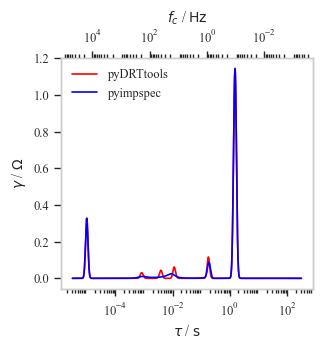

In [ ]:
DRT_array = [DRT_object_pyDRTtools, DRT_object_pyimpspec]

fig, ax = DRTPlot(DRT_array).plot_DRT()
display(fig)